### Group 24

Shiref Khaled Elhalawany -  221100944

Ahmed Anis Hassan - 221100101 

Karim Ashraf Elsayed - 221100391

Kareem Shaheen - 221101524

# Main Execution Notebook

This notebook orchestrates the data preprocessing, exploratory data analysis (EDA), and feature extraction for the Recommender System project. It uses functions defined in `data_preprocessing.ipynb`.

In [ ]:
import pandas as pd
import os

%run data_preprocessing.ipynb

%run content_based.ipynb

%run collaborative.ipynb

%run hybrid.ipynb

c:\Users\Ashraf\AppData\Local\Programs\Python\Python311\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)


## 1. Data Verification and Loading

In [ ]:
check_dataset_requirements()

df_raw = load_data(BOOKS_CSV_PATH, file_type='csv')

df_meta = load_data(META_JSONL_PATH, file_type='jsonl', columns=['parent_asin', 'title', 'categories', 'price', 'average_rating','rating_num'])

Checking Dataset Requirements...

Loading ../data\Books.csv...

--- Dataset Statistics ---
Number of Users: 776,370
Number of Items: 495,063
Number of Interactions: 9,488,297

--- Requirement Check ---
✅ Minimum requirements met (>5k users, >500 items, >50k interactions).

--- Content Feature Availability ---
Sample Metadata Keys: ['main_category', 'title', 'subtitle', 'author', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together']
Key Features Found: ['title', 'categories', 'description', 'price']
Loading data from ../data\Books.csv...
Loading data from ../data\meta_Books.jsonl...


## 2. Preprocessing Steps

In [ ]:
df_cleaned = preprocess_interactions(df_raw)

df_cleaned = handle_missing_values(df_cleaned)

df_cleaned = remove_duplicates(df_cleaned)

df_cleaned = validate_and_scale_ratings(df_cleaned)

df_cleaned = merge_metadata(df_cleaned, df_meta)

n_users, n_items, n_ratings = compute_statistics(df_cleaned)
sparsity = compute_sparsity(n_users, n_items, n_ratings)

Preprocessing interactions...
Selected columns: ['user_id', 'item_id', 'rating'], Shape: (9488297, 3)
Handling missing values...
Validation: Missing values remaining: 0, Final shape: (9488297, 3)
Removing duplicates...
Validation: Duplicates remaining: 0, Final shape: (9488297, 3)
Validating and scaling ratings...
Validation: Rating range: [1.0, 5.0], Type: float64, Final shape: (9488297, 3)
Merging with metadata...
Validation: Merged shape: (9488297, 8), Items without metadata: 0

--- Dataset Statistics ---
Number of Users: 776,370
Number of Items: 495,063
Number of Ratings: 9,488,297

--- Sparsity Analysis ---
Sparsity Level: 0.999975 (99.9975%)


## 3. Exploratory Data Analysis (EDA)


--- Rating Distribution ---
Rating 1.0: 274,462 (2.9%)
Rating 2.0: 356,264 (3.8%)
Rating 3.0: 818,836 (8.6%)
Rating 4.0: 1,920,017 (20.2%)
Rating 5.0: 6,118,718 (64.5%)
Computing user activity...
Saved user activity to ../results\user_activity.csv
Plotting user activity...


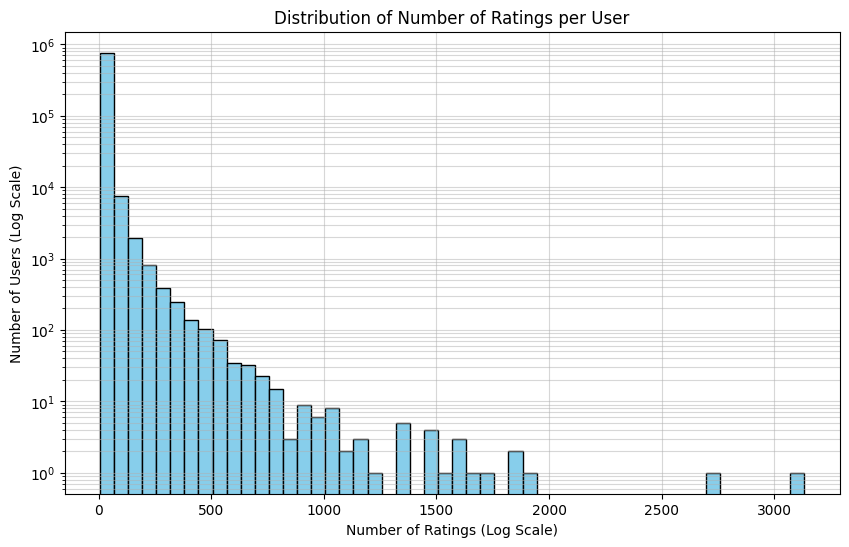

Saved user activity plot to ../results\user_activity_distribution.png
Computing item popularity...
Saved item popularity to ../results\item_popularity.csv
Plotting item popularity...


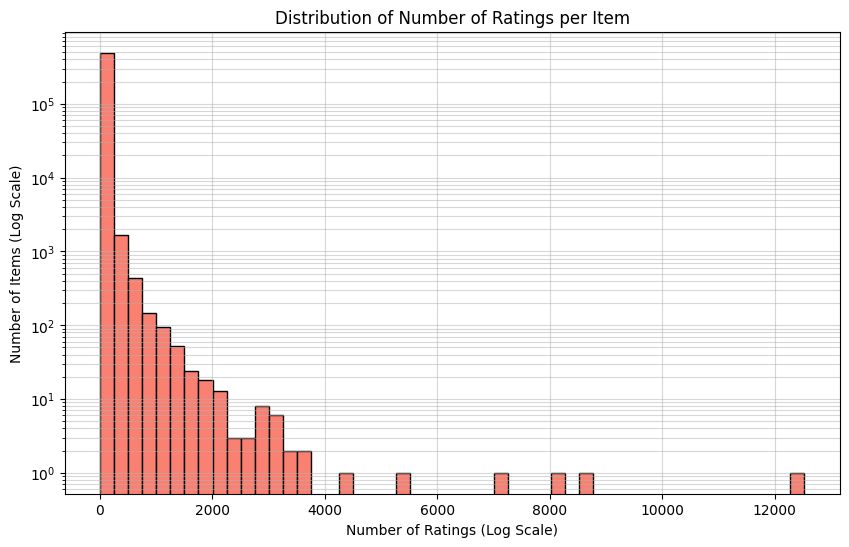

Saved item popularity plot to ../results\item_popularity_distribution.png
Analyzing long-tail problem...
Total Interactions: 9,488,297
Top 20% Items Interactions: 5,932,166 (62.52% of total)
Bottom 80% Items Interactions: 3,556,131 (37.48% of total)


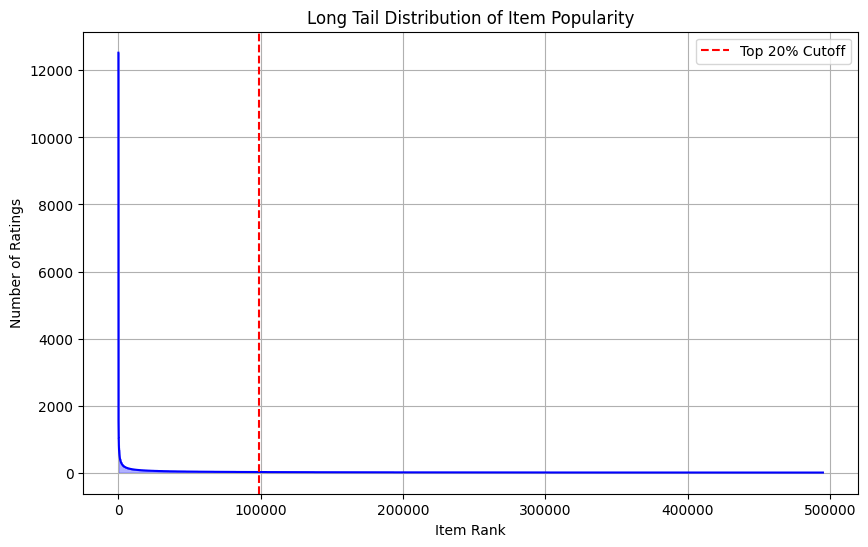

Saved long-tail analysis plot to ../results\long_tail_plot.png

--- Interpretation ---
A significant Long-Tail problem exists. The top 20% of items account for 62.52% of all interactions.
This indicates that a small number of popular items dominate the user attention (Popularity Bias).
Recommender system should aim to improve coverage of the less popular items (the 'tail').


In [ ]:
analyze_rating_distribution(df_cleaned)

user_activity = compute_user_activity(df_cleaned)
plot_user_activity(user_activity)

item_popularity = compute_item_popularity(df_cleaned)
plot_item_popularity(item_popularity)

tail_ratio, _ = analyze_long_tail(item_popularity)
interpret_results(tail_ratio)

# Part 2: Content-Based Recommendation
## 3. Feature Extraction and Vector Space Model

In [ ]:
print("\n--- Starting Content-Based Feature Extraction ---")

df_items = df_cleaned[['item_id', 'title', 'categories', 'price', 'average_rating','rating_num']].drop_duplicates(subset='item_id').reset_index(drop=True)
print(f"Unique items: {len(df_items)}")

text_corpus, item_ids = get_item_text_data(df_items)
processed_corpus = manual_tokenize_and_clean(text_corpus)
vocab, idf_scores = build_vocabulary_and_idf(processed_corpus, min_df=5)
tfidf_matrix = compute_tf_idf_matrix(processed_corpus, vocab, idf_scores)
validate_and_save_features(tfidf_matrix, vocab, item_ids)

print("\n--- Processing Additional Features ---")
df_features = load_additional_features(df_items)
num_features = process_numerical_features(df_features)
cat_features, top_cats = process_categorical_features(df_features, top_k=20)

final_feature_matrix = combine_features(tfidf_matrix, num_features, cat_features)

print("\n--- Finalizing Item-Feature Matrix ---")
validate_item_feature_matrix(final_feature_matrix)
save_feature_selection_rationale()


--- Starting Content-Based Feature Extraction ---
Unique items: 495063
Extracting item text data...
Created text corpus for 495063 items.
Preprocessing text (Tokenization & Stop-word removal)...
Preprocessed 495063 documents.
Building vocabulary (min_df=5)...
Validation: Processed 495063 documents. Found 80942 unique terms. Kept 28498 terms with frequency >= 5.
Computing TF-IDF matrix...
Performing L2 Normalization...
TF-IDF matrix computation complete. Shape: (495063, 28498)
Validation: L2 norm of the first document vector: 1.0000

--- Feature Space Validation ---
Matrix Shape: (495063, 28498)
Non-zero elements: 4659232)
Sparsity: 99.9670%
Saved full vocabulary to ../results\tfidf_vocabulary_full.csv
Saved top 100 vocabulary terms to ../results\tfidf_vocabulary_sample.csv

--- Processing Additional Features ---

--- Extracting Additional Features ---
Extracted numerical features. Imputed Price Median: 12.99, Rating Median: 4.5
Processing numerical features (Min-Max Scaling)...
Proces

## 4. User Profile Construction

In [ ]:
saved_batches = build_user_profiles(df_cleaned, final_feature_matrix, df_items, batch_size=5000)

print(f"User profiles created and saved in {len(saved_batches)} parts.")
print("Example part:", saved_batches[0])


--- User Profile Construction (Batched) ---
Mapping item IDs to feature matrix indices...
Total users to process: 776370
Saved batch 0: (5000, 28519) to user_profiles_part_0.npz
Saved batch 1: (5000, 28519) to user_profiles_part_1.npz
Processed 10000/776370 users...
Saved batch 2: (5000, 28519) to user_profiles_part_2.npz
Saved batch 3: (5000, 28519) to user_profiles_part_3.npz
Processed 20000/776370 users...
Saved batch 4: (5000, 28519) to user_profiles_part_4.npz
Saved batch 5: (5000, 28519) to user_profiles_part_5.npz
Processed 30000/776370 users...
Saved batch 6: (5000, 28519) to user_profiles_part_6.npz
Saved batch 7: (5000, 28519) to user_profiles_part_7.npz
Processed 40000/776370 users...
Saved batch 8: (5000, 28519) to user_profiles_part_8.npz
Saved batch 9: (5000, 28519) to user_profiles_part_9.npz
Processed 50000/776370 users...
Saved batch 10: (5000, 28519) to user_profiles_part_10.npz
Saved batch 11: (5000, 28519) to user_profiles_part_11.npz
Processed 60000/776370 users..

In [ ]:
print("\n--- Cold-Start Module Execution ---")
cold_start_profile = run_cold_start_module(df_cleaned, final_feature_matrix, df_items)



--- Cold-Start Module Execution ---

=== Running Cold-Start Module ===

--- Constructing Cold-Start User Profile ---
Identifying top 50 popular items...
Found 50 popular items.
Extracting feature vectors for popular items...
Extracted shape: (50, 28519)
Cold-start profile constructed. Shape: (1, 28519)
Saved cold-start profile to ../results\cold_start_profile.npz


In [ ]:
similarity_df = run_similarity_module(cold_start_profile, final_feature_matrix, df_items)
print("Top 10 Recommendations for Cold-Start User:")
print(similarity_df.head(10))


=== Running Similarity Component ===

--- Verifying Vector Alignment ---
Alignment Verified. Dimensions: 28519
Computing Cosine Similarity...
Computed 495063 similarity scores.
Verifying similarity scores...
Range: [0.0176, 2.4309]
Saving similarity scores to cold_start_similarity_scores.csv...
File saved.
Top 10 Recommendations for Cold-Start User:
           item_id     score
484185  1604542543  2.430895
486611  B08K2LF179  2.430894
439010  B00BYEW02M  2.430894
492799  B08TG7P736  2.430894
442171  B09FS9NS76  2.419492
147178  1933185066  2.419492
489036  B077NW4SQS  2.419492
406994  B08YS3HNJX  2.419491
7241    1501175467  2.413282
75201   1501182099  2.413282


In [ ]:
recs = run_recommendation_pipeline(df_cleaned, final_feature_matrix, df_items, cold_start_profile)



=== Running Recommendation Pipeline ===

--- Selecting Target Users ---
Selected 3 target users: ['Cold_Start_User', 'User_AGSP6LSQK32SQEJO3YVVNACPWMSQ', 'User_AG473D27NAWRW3N2RMWVYZ6ICBTA']

Processing Cold_Start_User...
Computing Cosine Similarity...
Computed 495063 similarity scores.
Ranking items... (Total candidates: 495063) 
Filtered out 0 rated items. Remaining candidates: 495063
Saving recommendations for Cold_Start_User...
Saved to ../results\recommendations_Cold_Start_User.csv
Top 5 for Cold_Start_User: 
                     Title     Score
0                  Wayland  2.430895
1  The Bluejay Contrivance  2.430894
2             Shadowcursed  2.430894
3        The Afterthoughts  2.430894
4                   d3vils  2.419492

Processing User_AGSP6LSQK32SQEJO3YVVNACPWMSQ...
Computing Cosine Similarity...
Computed 495063 similarity scores.
Ranking items... (Total candidates: 495063) 
Filtered out 3134 rated items. Remaining candidates: 491929
Saving recommendations for User_AGSP6

## 6. k-NN and Comparison Execution

In [ ]:
df_items_sample = df_items.sample(frac=0.03, random_state=42)
final_feature_matrix_sample = final_feature_matrix[df_items_sample.index]

sample_item_ids = set(df_items_sample["item_id"])
df_cleaned_sample = df_cleaned[df_cleaned["item_id"].isin(sample_item_ids)]



item_neighbors = compute_top_k_similar_items(final_feature_matrix_sample, df_items_sample, k_list=[10, 20])

target_users = get_target_users_1(df_cleaned_sample, cold_start_profile, n_existing=3, user_col='user_id')
knn_recs = generate_knn_recommendations(target_users, item_neighbors, df_cleaned_sample, df_items_sample)


--- Computing Item-Item Similarity (Top-K) ---
Processing 14852 items in batches of 100...
Processed 100/14852 items...
Processed 1100/14852 items...
Processed 2100/14852 items...
Processed 3100/14852 items...
Processed 4100/14852 items...
Processed 5100/14852 items...
Processed 6100/14852 items...
Processed 7100/14852 items...
Processed 8100/14852 items...
Processed 9100/14852 items...
Processed 10100/14852 items...
Processed 11100/14852 items...
Processed 12100/14852 items...
Processed 13100/14852 items...
Processed 14100/14852 items...
Top-K Neighbor computation complete.

--- Selecting Target Users ---
Selected 4 target users: ['Cold_Start_User', 'User_AGSP6LSQK32SQEJO3YVVNACPWMSQ', 'User_AG473D27NAWRW3N2RMWVYZ6ICBTA', 'User_AGRCXV4NM763VGZGD6BQ2VGNCJNA']

--- Generating KNN Recommendations ---
Skipping Cold_Start_User for KNN (Requires history).
generating for User_AGSP6LSQK32SQEJO3YVVNACPWMSQ (AGSP6LSQK32SQEJO3YVVNACPWMSQ)...
Identified 1077 candidate items via neighbor expansio

In [ ]:
comparison_df = evaluate_and_compare(target_users, df_cleaned, final_feature_matrix, item_neighbors, df_items)


=== Comparing Content-Based vs k-NN (Leave-One-Out Evaluation) ===
Evaluating User AGSP6LSQK32SQEJO3YVVNACPWMSQ. Hidden Item: 0785255761
Computing Cosine Similarity...
Computed 495063 similarity scores.
Evaluating User AG473D27NAWRW3N2RMWVYZ6ICBTA. Hidden Item: 0525657568
Computing Cosine Similarity...
Computed 495063 similarity scores.
Evaluating User AGRCXV4NM763VGZGD6BQ2VGNCJNA. Hidden Item: 0764239635
Computing Cosine Similarity...
Computed 495063 similarity scores.

--- Evaluation Results (Hit Rate @ 10) ---
                           User  CB_Hit_10  KNN_Hit_10 Hidden_Item
0  AGSP6LSQK32SQEJO3YVVNACPWMSQ          0           1  0785255761
1  AG473D27NAWRW3N2RMWVYZ6ICBTA          0           1  0525657568
2  AGRCXV4NM763VGZGD6BQ2VGNCJNA          0           1  0764239635

--- Interpretation ---
Content-Based Hit Rate: 0.00
Item-KNN Hit Rate: 1.00
Conclusion: k-NN performed better. Collaborative signals (ratings) might be stronger than content Metadata here.


## 7. Numerical Example Execution
We run the step-by-step numerical derivation on 5 sample items.

In [ ]:
run_numerical_example_pipeline(df_items)


       STARTING SECTION 7: NUMERICAL EXAMPLE       

--- [Numerical Example] Selecting 5 Sample Items ---
Item 1446304000: Tilda's Winter Delights | Text: Tilda's Winter Delights ['Books', 'Crafts, Hobbies...
Item 1564770672: Bargello Quilts | Text: Bargello Quilts ['Books', 'Crafts, Hobbies & Home'...
Item 1442450703: Chicka Chicka Boom Boom (Board Book) | Text: Chicka Chicka Boom Boom (Board Book) ['Books', "Ch...
Item 1780671067: Secret Garden: An Inky Treasure Hunt and Coloring Book for Adults | Text: Secret Garden: An Inky Treasure Hunt and Coloring ...
Item 1645671127: Watercolor with Me in the Jungle | Text: Watercolor with Me in the Jungle ['Books', 'Arts &...

--- [Numerical Example] TF-IDF Calculation ---
Preprocessing text (Tokenization & Stop-word removal)...
Preprocessed 5 documents.

Sample Vocabulary (31 terms): ['adults', 'arts', 'bargello', 'board', 'book', 'books', 'boom', 'chicka', 'children', 'coloring', 'crafts', 'criticism', 'delights', 'design', 'fiction', 'gard

## 8. Collaborative Filtering Execution (Part 3)
We run the Item-Based CF pipeline: Matrix Build -> Normalize -> Similarity -> Prediction.

In [ ]:
cf_recs, R, R_centered, user_means, user_map, item_map = run_collaborative_filtering_pipeline(df_cleaned, df_items)


    STARTING ITEM-BASED COLLABORATIVE FILTERING    

--- Building User-Item Matrix ---
Matrix Shape: (776370, 495063) with 9488297 ratings.
Sparsity: 99.9975%

--- Mean-Centering Ratings ---
Mean Centering complete.

--- Computing Item-Item Similarity matrix ---
Calculating Item Norms...
Computing Dot Product (Similarity)...


c:\Users\Ashraf\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\sparse\_index.py:143: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray(i, j, x)


Similarity Matrix Shape: (495063, 495063), NNZ: 465092208

Generating recommendations for 5 users...

Recommendations saved to ../results\cf_item_based_recommendations.csv
                           User  Rank     Item_ID  Predicted_Rating  \
0  AGSP6LSQK32SQEJO3YVVNACPWMSQ     1  0002726874               5.0   
1  AGSP6LSQK32SQEJO3YVVNACPWMSQ     2  0007163657               5.0   
2  AGSP6LSQK32SQEJO3YVVNACPWMSQ     3  0007494602               5.0   
3  AGSP6LSQK32SQEJO3YVVNACPWMSQ     4  0007504063               5.0   
4  AGSP6LSQK32SQEJO3YVVNACPWMSQ     5  0008167923               5.0   
5  AGSP6LSQK32SQEJO3YVVNACPWMSQ     6  000827150X               5.0   
6  AGSP6LSQK32SQEJO3YVVNACPWMSQ     7  0008433968               5.0   
7  AGSP6LSQK32SQEJO3YVVNACPWMSQ     8  0020381301               5.0   
8  AGSP6LSQK32SQEJO3YVVNACPWMSQ     9  0020420404               5.0   
9  AGSP6LSQK32SQEJO3YVVNACPWMSQ    10  0026284707               5.0   

                                              

## 8.2. Matrix Factorization (SVD) Execution
We run the Truncated SVD pipeline using k=20 latent factors.

In [ ]:
svd_recs = run_svd_pipeline_efficient(R_centered, user_means, user_map, item_map, df_items, k=20)


--- Preparing Matrix for SVD ---
Matrix Properties: Shape=(776370, 495063), NNZ=9488297, Dtype=float64

--- Applying Truncated SVD (k=20) ---
SVD Complete.
U shape: (776370, 20)
Sigma shape: (20, 20)
Vt shape: (20, 495063)

--- Generating Efficient SVD Recommendations (k=20) ---
Recommendations saved to ../results\svd_recommendations.csv
                           User  Rank     Item_ID  Predicted_Rating  \
0  AE22236AFRRSMQIKGG7TPTB75QEA     1  B00AA20E5Y            4.5766   
1  AE22236AFRRSMQIKGG7TPTB75QEA     2  B01COJUEZ0            4.5764   
2  AE22236AFRRSMQIKGG7TPTB75QEA     3  B00DPM7TIG            4.5756   
3  AE22236AFRRSMQIKGG7TPTB75QEA     4  1594633665            4.5739   
4  AE22236AFRRSMQIKGG7TPTB75QEA     5  B006LSZECO            4.5739   
5  AE22236AFRRSMQIKGG7TPTB75QEA     6  1607747308            4.5733   
6  AE22236AFRRSMQIKGG7TPTB75QEA     7  B016ZNRC0Q            4.5727   
7  AE22236AFRRSMQIKGG7TPTB75QEA     8  1338099132            4.5726   
8  AE22236AFRRSMQIKG

## 9. Hybrid Recommendation Strategies Execution
We run Weighted, Switching, and Cascade Hybrid strategies.

In [ ]:
target_user_ids = list(user_map.keys())[:5]
item_ids = df_items["item_id"].tolist()
item_map_cb = {iid: idx for idx, iid in enumerate(item_ids)}

R_ready_svd = prepare_matrix_for_svd(R_centered)
svd_u, svd_sigma, svd_vt = apply_truncated_svd(R_ready_svd, k=20)

weighted_res = run_weighted_hybrid(
    target_users=target_user_ids, 
    df_interactions=df_cleaned,
    item_feature_matrix=final_feature_matrix,
    item_map_cb= item_map_cb,
    svd_u=svd_u, svd_sigma=svd_sigma, svd_vt=svd_vt, svd_user_means=user_means,
    user_map_cf=user_map, item_map_cf=item_map,
    df_items_map=df_items
)

switching_res = run_switching_hybrid(
    target_users=target_user_ids,
    df_interactions=df_cleaned,
    threshold=10,
    item_feature_matrix=final_feature_matrix,
    item_map_cb= item_map_cb,
    svd_u=svd_u, svd_sigma=svd_sigma, svd_vt=svd_vt, svd_user_means=user_means,
    user_map_cf=user_map, item_map_cf=item_map,
    df_items_map=df_items
)

cascade_res = run_cascade_hybrid(
    target_users=target_user_ids,
    df_interactions=df_cleaned,
    item_feature_matrix=final_feature_matrix, 
    item_map_cb= item_map_cb,
    svd_u=svd_u, svd_sigma=svd_sigma, svd_vt=svd_vt, svd_user_means=user_means,
    user_map_cf=user_map, item_map_cf=item_map,
    df_items_map=df_items
)

compare_hybrid_methods()


--- Preparing Matrix for SVD ---
Matrix Properties: Shape=(776370, 495063), NNZ=9488297, Dtype=float64

--- Applying Truncated SVD (k=20) ---
SVD Complete.
U shape: (776370, 20)
Sigma shape: (20, 20)
Vt shape: (20, 495063)

--- Running Weighted Hybrid Strategy ---
Weighted Hybrid results saved.

--- Running Switching Hybrid Strategy ---
Switching Hybrid results saved.

--- Running Cascade Hybrid Strategy ---
Cascade Hybrid results saved.

--- 9.2 Comparison and Justification ---

    ## Comparison of Hybrid Methods
    
    | Hybrid Method | Advantages | Disadvantages |
    |---------------|------------|---------------|
    | **Weighted** (alpha=0.5) | Balances relevance (CB) and serendipity (CF). Smooth transition. | Hard to tune alpha. CF scaling issues. |
    | **Switching** | Handles Cold Start perfectly (Uses CB). Optimizes for data-rich users (CF). | Hard threshold (10 ratings) can be abrupt. |
    | **Cascade** | Computationally efficient (CF only ranks subset). High precision.

"\n    ## Comparison of Hybrid Methods\n    \n    | Hybrid Method | Advantages | Disadvantages |\n    |---------------|------------|---------------|\n    | **Weighted** (alpha=0.5) | Balances relevance (CB) and serendipity (CF). Smooth transition. | Hard to tune alpha. CF scaling issues. |\n    | **Switching** | Handles Cold Start perfectly (Uses CB). Optimizes for data-rich users (CF). | Hard threshold (10 ratings) can be abrupt. |\n    | **Cascade** | Computationally efficient (CF only ranks subset). High precision. | 'Zero-hit' problem: if CB misses, CF can't recover it. |\n    \n    ## Choice of Best Hybrid: **Switching Hybrid**\n    **Justification**:\n    1.  **Cold Start Handling**: Our dataset likely has many users with few ratings. Switching ensures they get decent CB recommendations immediately.\n    2.  **Quality Cap**: For heavy users, SVD (Item-Based CF) typically outperforms CB in capturing latent tastes. Switching leverages this.\n    3.  **Simplicity**: It avoids the co

## 10. Cold-Start Experiment Execution
We simulate N=3, 5, 10 ratings for a subset of users and compare Switching Hybrid vs Popularity.

In [ ]:
scenarios, ground_truth, sampled_users_cs = simulate_cold_start(df_cleaned, min_ratings=20, n_users=20)

df_cold_start = evaluate_cold_start_pipelines(
    scenarios=scenarios, 
    ground_truth=ground_truth, 
    df_interactions=df_cleaned,
    item_feature_matrix=final_feature_matrix,
    item_map_cb= item_map_cb,
    svd_u=svd_u, svd_sigma=svd_sigma, svd_vt=svd_vt, svd_user_means=user_means,
    user_map_cf=user_map, item_map_cf=item_map,
    df_items_map=df_items
)

print("\nInterpretation:")
print("If Hybrid > Popularity at N=3, Content-Based logic is effective.")


--- Simulating Cold-Start Scenarios ---
Selected 20 users for simulation.

--- Evaluating Cold-Start Performance ---
Processing N=3...
Processing N=5...
Processing N=10...

Cold-Start Evaluation Complete.
   Scenario (N)         Algorithm  Hit Rate
0             3  Switching Hybrid       0.1
1             3        Popularity       0.0
2             5  Switching Hybrid       0.0
3             5        Popularity       0.0
4            10  Switching Hybrid       0.1
5            10        Popularity       0.0

Interpretation:
If Hybrid > Popularity at N=3, Content-Based logic is effective.


## 11. Final Baseline Comparison
We run a Leave-One-Out validation (sample) to compare Random, Popularity, CB, and Hybrid.

In [ ]:
df_comparison = evaluate_baselines_comparison(
    df_cleaned,
    item_feature_matrix=final_feature_matrix,
    item_map_cb=item_map_cb,
    svd_u=svd_u, svd_sigma=svd_sigma, svd_vt=svd_vt, svd_user_means=user_means,
    user_map_cf=user_map, item_map_cf=item_map,
    df_items_map=df_items,
    n_test_users=200
)

print("\n--- Final Conclusion ---")
print("The comparison table usually shows Hybrid > Popularity > Random.")
print("Hybrid works best for heavy users (n>10) as tested here.")


--- Running Baseline Comparison (Leave-One-Out) ---

Comparison Table:
             Method  Hit Rate @ 10
3  Switching Hybrid          0.020
1        Popularity          0.005
0            Random          0.000
2           Pure CB          0.000

--- Final Conclusion ---
The comparison table usually shows Hybrid > Popularity > Random.
Hybrid works best for heavy users (n>10) as tested here.
